In [1]:
import sklearn
from sklearn.metrics import roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import json

In [99]:
!pip install rbo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 10.2 MB/s  0:00:01 10.6 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpy: filename=numpy-1.26.4-cp314-cp314-macosx_13_0_arm64.whl size=4694397 sha256=d81c4a8c36000cb8a4f9ae034a505cf6e22c80880c9335b60fa7a4e7db1acff4
  Stored in directory: /Users/waziz/Library/Caches/pip/wheels/9f/41/2d/41d9edbbdf1331835527392f3da54c7de611dc6ba3ef296215
Successfully built numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rbo]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.5.4 requires numpy>=2.1.0; python_version >= "3.13", but you 

In [134]:
from pathlib import Path
import rbo

def make_data_frame(folder_path="data/rank_correlations", sub_datasets=None, sub_generators=None, sub_metrics=None):

    # Load json
    folder = Path(folder_path)
    data = {}

    for json_file in folder.glob("*.json"):
        
        with json_file.open("r", encoding="utf-8") as f:
            dataset, model = "", ""

            if 'llama-3b' in json_file.name:
                model = 'llama-3b'
            elif 'llama-8b' in json_file.name:
                model = 'llama-8b'
            elif 'qwen-0.5b' in json_file.name:
                model = 'qwen-0.5b'
            elif 'qwen-7b' in json_file.name:
                model = 'qwen-7b'
            else:
                raise ValueError(f"Unkonwn model: {json_file}")
                
            if 'ambig_qa_single' in json_file.name:
                dataset = 'ambig_qa_single'
            elif 'ambig_qa_multiple' in json_file.name:
                dataset = 'ambig_qa_multiple'
            elif 'trivia_qa' in json_file.name:
                dataset = 'trivia_qa'
            else:
                raise ValueError(f"Unkonwn dataset: {json_file}")

            data[json_file.name] = {'dataset': dataset, 'model': model, 'data': json.load(f)}
    
    
    headers = ['Dataset', 'Generator', 'Judge type', 'Judge', 'F1', 'Rank correlation', 'Metric']
    table = []
    
    for k, v in data.items():
        # print(v['dataset'], v['model'])
        # print()
        for rec in v['data']['data']:        
            # print("\t", rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'])
    
            rsim = rbo.RankingSimilarity(rec['judge_rankings'], np.arange(len(rec['judge_rankings'])) + 1).rbo()        
            jf = rec['judge'].split("_")[0]
            if jf == 'llm':
                jf = rec['judge'].split("_")[0] + "-" + rec['judge'].split("_")[-1]
            
            # table.append([v['dataset'], v['model'],  jf, rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'], rec['rank_correlation_spearman']['spearmanr'], rsim])
            table.append([v['dataset'], v['model'],  jf, rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'], 'Kendall'])
            table.append([v['dataset'], v['model'],  jf, rec['judge'], rec['f1_score'], rec['rank_correlation_spearman']['spearmanr'], 'Spearman'])
            table.append([v['dataset'], v['model'],  jf, rec['judge'], rec['f1_score'], rsim, 'RBO'])

    df = pd.DataFrame(
        table,
        columns=headers,
    )
    if sub_datasets:
        df = df[df['Dataset'].isin(sub_datasets)]
    if sub_generators:
        df = df[df['Generator'].isin(sub_generators)]
    if sub_metrics:
        df = df[df['Metric'].isin(sub_metrics)]
    return df

In [137]:
!mkdir -p otherstuff

In [142]:
df = make_data_frame(
    sub_datasets={'trivia_qa'},
    sub_generators={'qwen-7b', 'llama-8b'},
    sub_metrics={'Kendall', 'RBO'}
)
# df

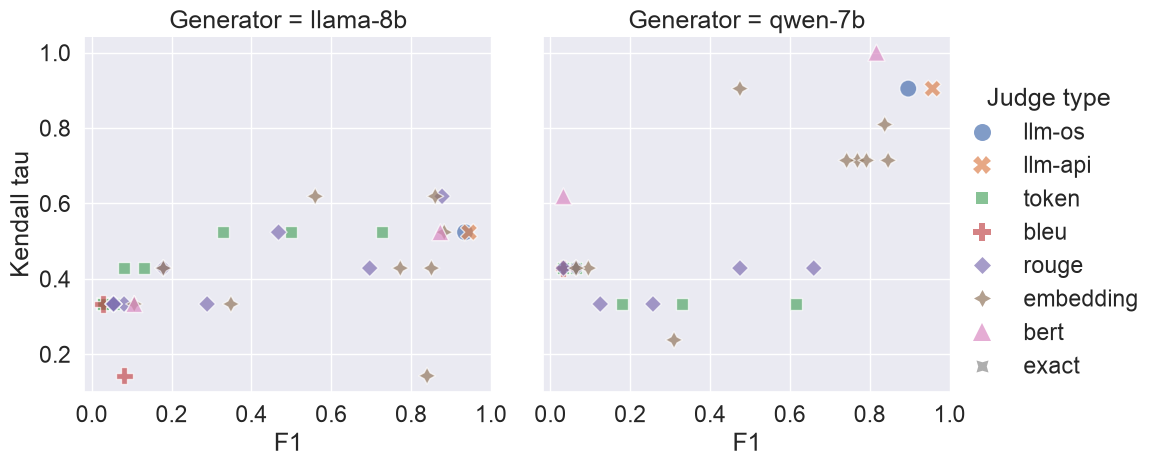

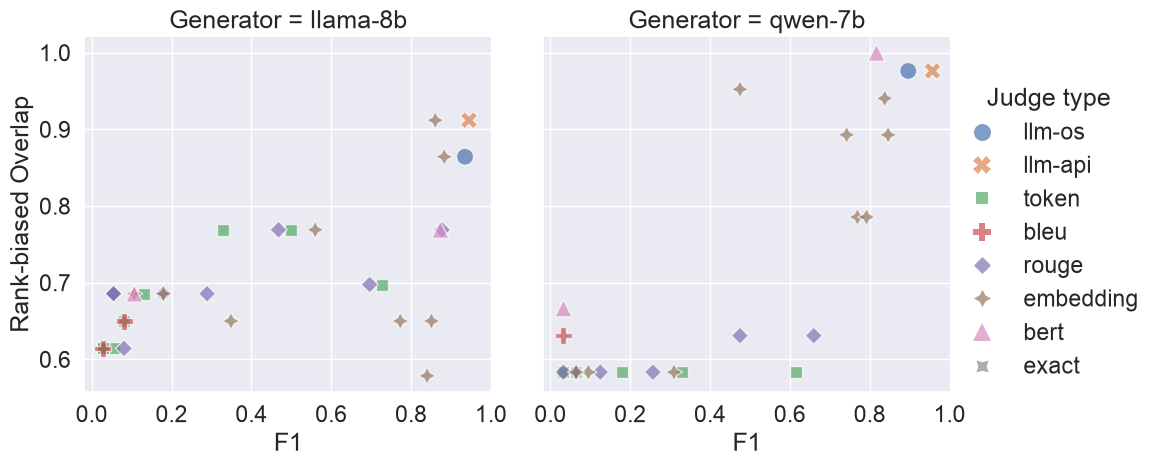

In [143]:
sns.set_theme(style="darkgrid")

for metric in ['Kendall', 'RBO']:

    with sns.plotting_context("notebook", font_scale=1.5):
        
        g= sns.relplot(
            df[df['Metric']==metric],
            x='F1',
            y='Rank correlation',
            style='Judge type',
            hue='Judge type',
            # hue='UQ',
            # style='annotation',
            # row='Metric',
            col='Generator',
            s=150,
            alpha=0.7, 
            col_order=['llama-8b', 'qwen-7b'],
            
        )
        if metric == 'Kendall':
            g.set_ylabels("Kendall tau")
        else:
            g.set_ylabels("Rank-biased Overlap")
    g.savefig(f"otherstuff/F1-{metric}-triviaqa.pdf")